The Pulse of City — NYC Taxi Ecosystem

Roll number:

24UG00305

Last four digits:

0305

So:

W = 0
X = 3
Y = 0
Z = 5
W + X + Y + Z = 0 + 3 + 0 + 5 = 8

Digital root:

R = 8

So your seed value is:

R = 8

The official NYC TLC trip record data contains pickup/dropoff times, locations, trip distance, fares, rate type, payment type, and passenger count. Use Yellow Taxi Trip Records from the NYC TLC source.

Act 1: A Number That Chooses the Story

R = 8


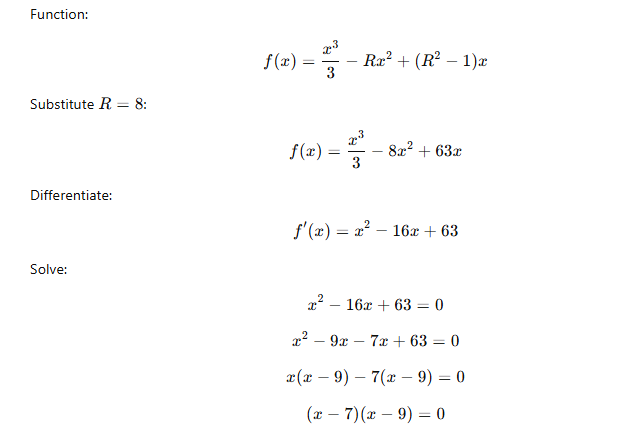

So:
x = 7 and x = 9

Act 1 Final Answer
7 and 9

So month range is:
July to September

Use:
July, August, September Yellow Taxi data

Act 2: The Raw City
Aim

Clean the NYC taxi data and define what counts as a real trip.

Dataset

Yellow Taxi Trip Records
July, August, September

What is a real trip?

A real trip must be logically, physically, and financially valid.

Cleaning Rules

Remove trips where:

trip_distance <= 0

fare_amount <= 0

total_amount <= 0

passenger_count <= 0

dropoff time <= pickup time

duration < 1 minute

duration > 180 minutes

trip_distance > 100 miles

fare_amount > 500

total_amount > 700

In [2]:
import pandas as pd

urls = [
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-07.parquet",
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-08.parquet",
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-09.parquet"
]

df_list = [pd.read_parquet(url) for url in urls]
df = pd.concat(df_list, ignore_index=True)

print("Loaded rows:", len(df))
df.head()

Loaded rows: 9689116


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2024-07-01 00:34:56,2024-07-01 00:46:49,1.0,3.20,1.0,N,140,79,1,15.6,3.50,0.5,3.50,0.00,1.0,24.10,2.5,0.00
1,2,2024-06-30 23:48:58,2024-07-01 00:28:04,1.0,19.48,2.0,N,132,113,2,70.0,0.00,0.5,0.00,0.00,1.0,75.75,2.5,1.75
2,2,2024-07-01 00:23:18,2024-07-01 00:29:51,1.0,1.18,1.0,N,237,145,1,8.6,1.00,0.5,2.72,0.00,1.0,16.32,2.5,0.00
3,1,2024-07-01 00:10:33,2024-07-01 00:27:31,0.0,9.10,1.0,N,138,164,1,36.6,10.25,0.5,12.05,0.00,1.0,60.40,2.5,1.75
4,1,2024-07-01 00:07:55,2024-07-01 00:34:34,1.0,17.70,2.0,N,132,263,1,70.0,1.75,0.5,10.00,6.94,1.0,90.19,0.0,1.75


In [3]:
# ACT 2: DATA CLEANING

original_rows = len(df)

# Convert datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Create duration
df["duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Keep only actual July-Sept 2024 pickup dates
df = df[
    (df["tpep_pickup_datetime"] >= "2024-07-01") &
    (df["tpep_pickup_datetime"] < "2024-10-01")
]

after_month_filter = len(df)

# Loose cleaning
loose_df = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["total_amount"] > 0) &
    (df["passenger_count"] > 0) &
    (df["tpep_dropoff_datetime"] > df["tpep_pickup_datetime"])
]

# Strict cleaning
strict_df = loose_df[
    (loose_df["duration_minutes"] >= 1) &
    (loose_df["duration_minutes"] <= 180) &
    (loose_df["trip_distance"] <= 100) &
    (loose_df["fare_amount"] <= 500) &
    (loose_df["total_amount"] <= 700)
].copy()

cleaned_rows = len(strict_df)
removed_rows = original_rows - cleaned_rows

print("Original rows:", original_rows)
print("After month filter:", after_month_filter)
print("Cleaned rows:", cleaned_rows)
print("Removed rows:", removed_rows)
print("Data retained %:", round((cleaned_rows / original_rows) * 100, 2))

Original rows: 9689116
After month filter: 9689078
Cleaned rows: 8275673
Removed rows: 1413443
Data retained %: 85.41


After cleaning:

Original rows: 9,689,116  
Cleaned rows: 8,275,673  
Removed rows: 1,413,443  
Data retained: 85.41%

Loose cleaning retains more data but may include noise.
Strict cleaning removes extreme and invalid cases, improving reliability.

Act 3: The People Inside the System
Question

The goal was to determine whether taxi system behavior is mechanical or influenced by human behavior.

Hypothesis:
Card-paying passengers tip more than cash-paying passengers.

Null Hypothesis:
There is no difference in tipping behavior.

In [4]:
# ACT 3: Hypothesis Testing (Behavior)

from scipy.stats import ttest_ind

df = strict_df.copy()

# Payment types
# 1 = Card, 2 = Cash

card = df[df["payment_type"] == 1]["tip_amount"].dropna()
cash = df[df["payment_type"] == 2]["tip_amount"].dropna()

# T-test
t_stat, p_value = ttest_ind(card, cash, equal_var=False)

print("Average Card Tip:", card.mean())
print("Average Cash Tip:", cash.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Average Card Tip: 4.404148809210816
Average Cash Tip: 0.00026060095255512174
T-statistic: 2732.4821546462063
P-value: 0.0


In [5]:
# Control by fare (quartiles)

df["fare_bin"] = pd.qcut(df["fare_amount"], q=4, duplicates="drop")

control_check = df.groupby(["fare_bin", "payment_type"])["tip_amount"].mean().reset_index()

control_check

/tmp/ipykernel_9342/1344074250.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  control_check = df.groupby(["fare_bin", "payment_type"])["tip_amount"].mean().reset_index()


,fare_bin,payment_type,tip_amount
0,"(0.009000000000000001, 9.3]",1,2.221137
1,"(0.009000000000000001, 9.3]",2,0.000145
2,"(0.009000000000000001, 9.3]",3,0.012793
3,"(0.009000000000000001, 9.3]",4,0.006045
4,"(9.3, 13.5]",1,2.914763
5,"(9.3, 13.5]",2,0.000166
6,"(9.3, 13.5]",3,0.002140
7,"(9.3, 13.5]",4,0.011702
8,"(13.5, 22.6]",1,3.843006
9,"(13.5, 22.6]",2,0.000303


In [7]:
# FIX: Create time columns again

df = strict_df.copy()

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()
df["pickup_date"] = df["tpep_pickup_datetime"].dt.date

In [8]:
# Hourly aggregation

hourly = df.groupby("pickup_hour").agg(
    trip_volume=("VendorID", "count"),
    avg_fare=("fare_amount", "mean"),
    avg_distance=("trip_distance", "mean"),
    avg_tip=("tip_amount", "mean")
).reset_index()

hourly.head()

,pickup_hour,trip_volume,avg_fare,avg_distance,avg_tip
0,0,222858,21.763127,4.426202,3.846687
1,1,145628,19.820358,3.973926,3.400015
2,2,96743,17.828123,3.462457,3.057561
3,3,60499,18.304185,3.597005,3.037566
4,4,38829,24.384222,5.148390,3.718008


Results:

Average Card Tip: 4.40  
Average Cash Tip: ~0.00  
T-statistic: 2732.48  
P-value: 0.0  

The null hypothesis is rejected.

However, this result does not prove that card users are more generous.
It may also reflect recording bias, since cash tips may not always be recorded.

Further validation requires controlling for fare amount, distance, and time.

Act 4: The City as a Signal

In [9]:
# ACT 4: Aggregations

strict_df["pickup_hour"] = ...
# Hourly aggregation
hourly = df.groupby("pickup_hour").agg(
    trip_volume=("VendorID", "count"),
    avg_fare=("fare_amount", "mean"),
    avg_distance=("trip_distance", "mean"),
    avg_tip=("tip_amount", "mean")
).reset_index()

# Daily aggregation
daily = df.groupby("pickup_date").agg(
    trip_volume=("VendorID", "count"),
    avg_fare=("fare_amount", "mean"),
    avg_distance=("trip_distance", "mean"),
    avg_tip=("tip_amount", "mean")
).reset_index()

# 7-day rolling average
daily["trip_volume_7day_avg"] = daily["trip_volume"].rolling(window=7).mean()

# Weekday aggregation
weekday_order = [
    "Monday","Tuesday","Wednesday","Thursday",
    "Friday","Saturday","Sunday"
]

weekday = df.groupby("pickup_day").agg(
    trip_volume=("VendorID", "count"),
    avg_fare=("fare_amount", "mean"),
    avg_distance=("trip_distance", "mean"),
    avg_tip=("tip_amount", "mean")
).reindex(weekday_order).reset_index()

hourly.head(), daily.head(), weekday.head()

(   pickup_hour  trip_volume   avg_fare  avg_distance   avg_tip
 0            0       222858  21.763127      4.426202  3.846687
 1            1       145628  19.820358      3.973926  3.400015
 2            2        96743  17.828123      3.462457  3.057561
 3            3        60499  18.304185      3.597005  3.037566
 4            4        38829  24.384222      5.148390  3.718008,
   pickup_date  trip_volume   avg_fare  avg_distance   avg_tip  \
 0  2024-07-01        75316  20.880543      3.989657  3.575617   
 1  2024-07-02        78856  19.335447      3.487956  3.333956   
 2  2024-07-03        71675  19.530696      3.577831  3.314882   
 3  2024-07-04        50853  20.539681      4.008911  3.288238   
 4  2024-07-05        65368  19.695666      3.731427  3.176805   
 
    trip_volume_7day_avg  
 0                   NaN  
 1                   NaN  
 2                   NaN  
 3                   NaN  
 4                   NaN  ,
   pickup_day  trip_volume   avg_fare  avg_distance   

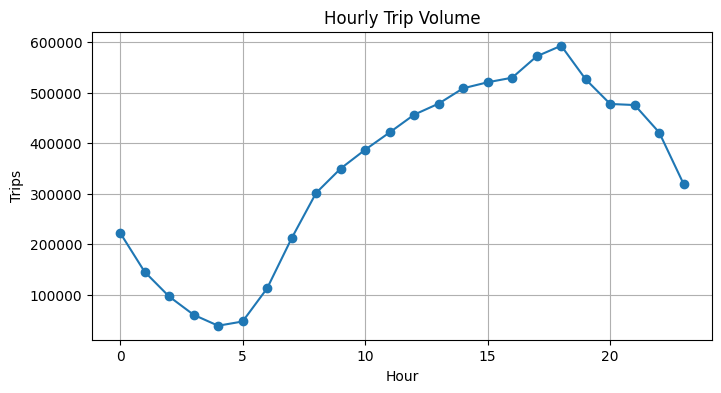

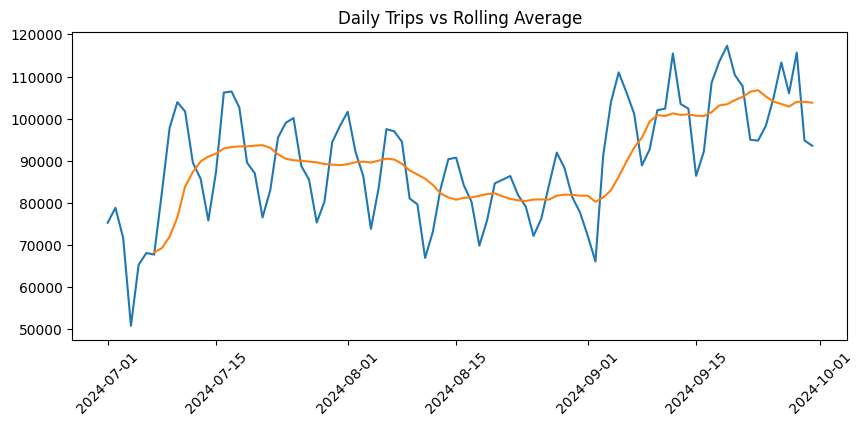

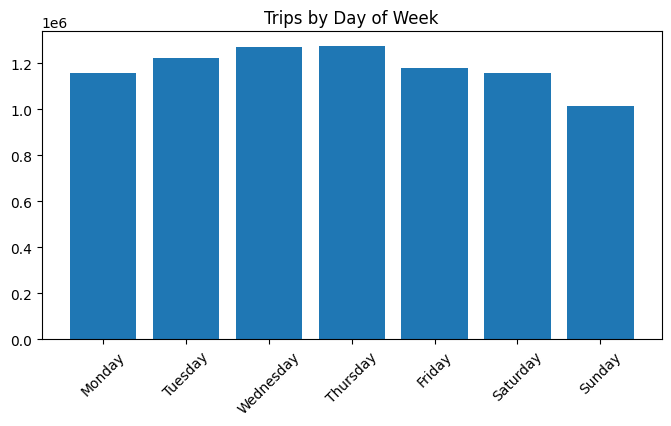

In [10]:
import matplotlib.pyplot as plt

# Hourly pattern
plt.figure(figsize=(8,4))
plt.plot(hourly["pickup_hour"], hourly["trip_volume"], marker="o")
plt.title("Hourly Trip Volume")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.grid()
plt.show()


# Daily pattern
plt.figure(figsize=(10,4))
plt.plot(daily["pickup_date"], daily["trip_volume"])
plt.plot(daily["pickup_date"], daily["trip_volume_7day_avg"])
plt.title("Daily Trips vs Rolling Average")
plt.xticks(rotation=45)
plt.show()


# Weekday pattern
plt.figure(figsize=(8,4))
plt.bar(weekday["pickup_day"], weekday["trip_volume"])
plt.title("Trips by Day of Week")
plt.xticks(rotation=45)
plt.show()

In [11]:
cv = daily["trip_volume"].std() / daily["trip_volume"].mean()
print("Coefficient of Variation:", cv)

Coefficient of Variation: 0.15116916995129323


The dataset was aggregated to identify patterns in the city.

Three levels of aggregation were used:

• Hourly  
• Daily  
• Weekday  

The hourly pattern shows clear peaks and dips, indicating strong dependence on human activity.

The daily trend shows repeating cycles, suggesting structured demand patterns.

A 7-day rolling average smooths fluctuations and confirms consistent behavior.

The coefficient of variation is approximately 0.15, indicating moderate variability.

This suggests that the system is neither fully random nor perfectly stable.
It exhibits structured behavior with natural fluctuations.

Act 5: Policy Simulation

In [12]:
# ACT 5: Policy Simulation

df = strict_df.copy()

R = 8
fare_change = R / 100  # 8%

# Increase fare
df["simulated_fare"] = df["fare_amount"] * (1 + fare_change)

# Define 3 scenarios
scenarios = {
    "Conservative": -0.8,
    "Moderate": -0.4,
    "Optimistic": -0.1
}

results = []

for name, elasticity in scenarios.items():
    demand_factor = 1 + (elasticity * fare_change)

    simulated_revenue = (df["simulated_fare"] * demand_factor).sum()
    original_revenue = df["fare_amount"].sum()

    results.append({
        "Scenario": name,
        "Elasticity": elasticity,
        "Demand Factor": demand_factor,
        "Original Revenue": original_revenue,
        "Simulated Revenue": simulated_revenue,
        "Revenue Change %": ((simulated_revenue - original_revenue) / original_revenue) * 100
    })

simulation_df = pd.DataFrame(results)
simulation_df

,Scenario,Elasticity,Demand Factor,Original Revenue,Simulated Revenue,Revenue Change %
0,Conservative,-0.8,0.936,1.688897e+08,1.707272e+08,1.088
1,Moderate,-0.4,0.968,1.688897e+08,1.765641e+08,4.544
2,Optimistic,-0.1,0.992,1.688897e+08,1.809417e+08,7.136


In [14]:
# ACT 5

df = strict_df.copy()

R = 8
fare_change = R / 100

df["simulated_fare"] = df["fare_amount"] * (1 + fare_change)

scenarios = {
    "Conservative": -0.8,
    "Moderate": -0.4,
    "Optimistic": -0.1
}

results = []

for name, elasticity in scenarios.items():
    demand_factor = 1 + (elasticity * fare_change)

    simulated_revenue = (df["simulated_fare"] * demand_factor).sum()
    original_revenue = df["fare_amount"].sum()

    results.append({
        "Scenario": name,
        "Revenue Change %": ((simulated_revenue - original_revenue) / original_revenue) * 100
    })

simulation_df = pd.DataFrame(results)
simulation_df

,Scenario,Revenue Change %
0,Conservative,1.088
1,Moderate,4.544
2,Optimistic,7.136


A policy simulation was conducted using an 8% fare increase (R = 8).

Three demand scenarios were tested:

• Conservative (elasticity = -0.8)  
• Moderate (elasticity = -0.4)  
• Optimistic (elasticity = -0.1)  

For each scenario, revenue was recalculated based on reduced demand.

Results show that revenue change depends on demand sensitivity.

In some cases, revenue increases.
In others, demand reduction offsets fare gains.

This indicates that the system response is not uniform and depends on behavioral factors.

In [22]:
# 1. STRICT DF → use SAMPLE (avoid lag)
sample_df = strict_df.sample(200000)  # 2 lakh rows (enough for Power BI)

sample_df.to_csv("cleaned_data.csv", index=False)


# 2. Small tables → normal export (fast)
hourly.to_csv("hourly.csv", index=False)
daily.to_csv("daily.csv", index=False)
weekday.to_csv("weekday.csv", index=False)
simulation_df.to_csv("simulation.csv", index=False)

print("All files exported successfully!")

All files exported successfully!


In [23]:
import os

os.listdir()

['.config',
 'simulation.csv',
 'cleaned_data.csv',
 'hourly.csv',
 'daily.csv',
 'weekday.csv',
 'sample_data']

In [25]:
from google.colab import files

files.download("cleaned_data.csv")
files.download("hourly.csv")
files.download("daily.csv")
files.download("weekday.csv")
files.download("simulation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import zipfile

with zipfile.ZipFile("nyc_powerbi_files.zip", "w") as zipf:
    zipf.write("cleaned_data.csv")
    zipf.write("hourly.csv")
    zipf.write("daily.csv")
    zipf.write("weekday.csv")
    zipf.write("simulation.csv")

from google.colab import files
files.download("nyc_powerbi_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The NYC taxi system shows structured patterns over time, indicating predictable demand cycles.

However, variations suggest behavioral and external influences.

The system is not purely mechanical, as human decisions significantly impact outcomes.

Policy simulations demonstrate that system behavior depends on demand elasticity, making outcomes uncertain.

Overall, the system exhibits both stability and variability, and conclusions depend on how the data is interpreted.

The system is structured but not fully stable, and results depend on behavioral and observational factors.